# Lab 4: Advanced Missing Data Handling



In [1]:
needed <- c("naniar", "skimr", "dplyr")
to_install <- needed[!(needed %in% installed.packages()[, "Package"])]
if (length(to_install) > 0) install.packages(to_install, repos = "https://cloud.r-project.org")

library(naniar)
library(skimr)
library(dplyr)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gridExtra’, ‘plyr’, ‘norm’, ‘visdat’, ‘viridis’, ‘UpSetR’



Attaching package: ‘skimr’


The following object is masked from ‘package:naniar’:

    n_complete



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## 1. Load the UCI Adult (Census Income) dataset

In [2]:
url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

col_names <- c("age","workclass","fnlwgt","education","education_num","marital_status",
               "occupation","relationship","race","sex","capital_gain","capital_loss",
               "hours_per_week","native_country","income")

adult <- tryCatch(
  read.csv(url, header = FALSE, col.names = col_names, na.strings = c("?", " ?"),
            strip.white = TRUE, stringsAsFactors = FALSE),
  error = function(e) {
    message("Could not download from UCI (no internet in this environment?). Generating a synthetic fallback dataset instead.")
    set.seed(7)
    n <- 2000
    data.frame(
      age = sample(17:80, n, replace = TRUE),
      workclass = sample(c("Private","Self-emp","Government","Without-pay"), n, replace = TRUE),
      fnlwgt = sample(10000:500000, n, replace = TRUE),
      education = sample(c("Bachelors","HS-grad","Masters","Some-college","Doctorate"), n, replace = TRUE),
      education_num = sample(1:16, n, replace = TRUE),
      marital_status = sample(c("Married","Never-married","Divorced","Widowed"), n, replace = TRUE),
      occupation = sample(c("Tech-support","Sales","Exec-managerial","Craft-repair","Prof-specialty"), n, replace = TRUE),
      relationship = sample(c("Husband","Wife","Not-in-family","Own-child"), n, replace = TRUE),
      race = sample(c("White","Black","Asian-Pac-Islander","Other"), n, replace = TRUE),
      sex = sample(c("Male","Female"), n, replace = TRUE),
      capital_gain = sample(0:5000, n, replace = TRUE),
      capital_loss = sample(0:2000, n, replace = TRUE),
      hours_per_week = sample(1:80, n, replace = TRUE),
      native_country = sample(c("United-States","Mexico","India","Germany","Other"), n, replace = TRUE),
      income = sample(c("<=50K",">50K"), n, replace = TRUE),
      stringsAsFactors = FALSE
    )
  }
)

str(adult)
head(adult)


'data.frame':	32561 obs. of  15 variables:
 $ age           : int  39 50 38 53 28 37 49 52 31 42 ...
 $ workclass     : chr  "State-gov" "Self-emp-not-inc" "Private" "Private" ...
 $ fnlwgt        : int  77516 83311 215646 234721 338409 284582 160187 209642 45781 159449 ...
 $ education     : chr  "Bachelors" "Bachelors" "HS-grad" "11th" ...
 $ education_num : int  13 13 9 7 13 14 5 9 14 13 ...
 $ marital_status: chr  "Never-married" "Married-civ-spouse" "Divorced" "Married-civ-spouse" ...
 $ occupation    : chr  "Adm-clerical" "Exec-managerial" "Handlers-cleaners" "Handlers-cleaners" ...
 $ relationship  : chr  "Not-in-family" "Husband" "Not-in-family" "Husband" ...
 $ race          : chr  "White" "White" "White" "Black" ...
 $ sex           : chr  "Male" "Male" "Male" "Male" ...
 $ capital_gain  : int  2174 0 0 0 0 0 0 0 14084 5178 ...
 $ capital_loss  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hours_per_week: int  40 13 40 40 40 40 16 45 50 40 ...
 $ native_country: chr  "United-States" "Uni

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
6,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


## Simulate realistic data-entry problems



In [3]:
set.seed(99)
adult_dirty <- adult
n <- nrow(adult_dirty)

na_idx      <- sample(1:n, 8)
blank_idx   <- sample(setdiff(1:n, na_idx), 8)
nan_idx     <- sample(setdiff(1:n, c(na_idx, blank_idx)), 5)
age999_idx  <- sample(setdiff(1:n, c(na_idx, blank_idx, nan_idx)), 5)

adult_dirty$hours_per_week[na_idx]   <- NA
adult_dirty$workclass[blank_idx]     <- ""
adult_dirty$capital_gain[nan_idx]    <- NaN
adult_dirty$age[age999_idx]          <- 999

cat("Injected NA in hours_per_week at rows:", na_idx, "\n")
cat("Injected blank strings in workclass at rows:", blank_idx, "\n")
cat("Injected NaN in capital_gain at rows:", nan_idx, "\n")
cat("Injected age = 999 at rows:", age999_idx, "\n")


Injected NA in hours_per_week at rows: 5552 7457 12076 32278 2294 30581 11235 19306 
Injected blank strings in workclass at rows: 23492 11494 3201 358 12709 8976 12313 9191 
Injected NaN in capital_gain at rows: 23468 6728 6413 11995 14948 
Injected age = 999 at rows: 5281 21095 5976 17933 22961 


## 2. Task 1 - Identify different forms of missing/invalid data

### `NA` vs `NaN` vs `NULL` vs `""`


In [4]:
cat("Count of NA in hours_per_week:", sum(is.na(adult_dirty$hours_per_week)), "\n")

cat("Count of NaN in capital_gain:", sum(is.nan(adult_dirty$capital_gain)), "\n")
cat("Note: is.na() ALSO flags NaN because NaN is a subtype of NA in R:\n")
cat("  is.na(NaN) =", is.na(NaN), " | is.nan(NA) =", is.nan(NA), "\n")

x <- NULL
cat("\nis.null(x) where x <- NULL:", is.null(x), "\n")

some_list <- list(a = 1, b = NULL)
cat("A list element explicitly set to NULL simply does not exist as a slot:\n")
print(some_list)
cat("length(some_list):", length(some_list), "\n")

cell_attempt <- tryCatch({
  adult_dirty$age[1] <- NULL
  "assignment succeeded"
}, error = function(e) paste("Error:", conditionMessage(e)))
cat("\nAttempting to set a single data-frame cell to NULL ->", cell_attempt, "\n")
cat("(You cannot store NULL inside a single cell of a vector/column; a cell is always\n",
    " some value, and the correct way to mark a missing cell is NA, not NULL.)\n")


Count of NA in hours_per_week: 8 
Count of NaN in capital_gain: 5 
Note: is.na() ALSO flags NaN because NaN is a subtype of NA in R:
  is.na(NaN) = TRUE  | is.nan(NA) = FALSE 

is.null(x) where x <- NULL: TRUE 
A list element explicitly set to NULL simply does not exist as a slot:
$a
[1] 1

$b
NULL

length(some_list): 2 

Attempting to set a single data-frame cell to NULL -> Error: replacement has length zero 
(You cannot store NULL inside a single cell of a vector/column; a cell is always
  some value, and the correct way to mark a missing cell is NA, not NULL.)


In [5]:
blank_count <- sum(adult_dirty$workclass == "", na.rm = TRUE)
na_workclass_count <- sum(is.na(adult_dirty$workclass))
cat("Blank string count in workclass:", blank_count, "\n")
cat("Genuine NA count in workclass (e.g. from '?' in the real UCI data):", na_workclass_count, "\n")

impossible_age_count <- sum(adult_dirty$age == 999, na.rm = TRUE)
cat("Impossible age (999) count:", impossible_age_count, "\n")


Blank string count in workclass: 8 
Genuine NA count in workclass (e.g. from '?' in the real UCI data): 1836 
Impossible age (999) count: 5 


In [6]:
miss_var_summary(adult_dirty)


variable,n_miss,pct_miss
<chr>,<int>,<num>
occupation,1843,5.66
workclass,1836,5.64
native_country,583,1.79
hours_per_week,8,0.024[4m6[24m
capital_gain,5,0.015[4m4[24m
age,0,0
fnlwgt,0,0
education,0,0
education_num,0,0


## 3. Task 2 - Missing-data treatment strategy

In [7]:
adult_clean <- adult_dirty

adult_clean$age[adult_clean$age == 999] <- NA

is_blank_or_na <- is.na(adult_clean$workclass) | adult_clean$workclass == ""
is_blank_or_na[is.na(is_blank_or_na)] <- TRUE
adult_clean$workclass[is_blank_or_na] <- "Unknown"

median_hours <- median(adult_clean$hours_per_week, na.rm = TRUE)
adult_clean$hours_per_week[is.na(adult_clean$hours_per_week)] <- median_hours

median_age <- median(adult_clean$age, na.rm = TRUE)
adult_clean$age[is.na(adult_clean$age)] <- median_age

before_rows <- nrow(adult_clean)
adult_clean <- adult_clean[!is.nan(adult_clean$capital_gain), ]
after_rows <- nrow(adult_clean)
cat("Rows removed due to unrecoverable NaN in capital_gain:", before_rows - after_rows, "\n")

complete_flags <- complete.cases(adult_clean)
cat("Complete observations:", sum(complete_flags), "out of", length(complete_flags), "\n")
cat("Incomplete observations remaining:", sum(!complete_flags), "\n")


Rows removed due to unrecoverable NaN in capital_gain: 5 
Complete observations: 30157 out of 32556 
Incomplete observations remaining: 2399 


## 4. Task 3 - Custom median-imputation function

In [8]:
median_impute <- function(x) {
  if (!is.numeric(x)) stop("median_impute() expects a numeric vector.")
  med <- median(x, na.rm = TRUE)
  missing_idx <- is.na(x)
  x[missing_idx] <- med
  x
}

demo_vec <- c(10, NA, 20, NA, 30, 40)
cat("Original: ", demo_vec, "\n")
cat("Imputed:  ", median_impute(demo_vec), "\n")

adult_clean$education_num <- median_impute(adult_clean$education_num)


Original:  10 NA 20 NA 30 40 
Imputed:   10 25 20 25 30 40 


## 5. Task 4 - Missingness analysis before vs after cleaning

In [9]:
cat("---- BEFORE cleaning (adult_dirty) ----\n")
n_miss_before <- sum(is.na(adult_dirty)) + sum(adult_dirty$workclass == "", na.rm = TRUE)
pct_miss_before <- round(100 * n_miss_before / (nrow(adult_dirty) * ncol(adult_dirty)), 3)
cat("Total missing/invalid cells (NA + blank strings):", n_miss_before, "\n")
cat("Percentage of all cells:", pct_miss_before, "%\n\n")

cat("---- AFTER cleaning (adult_clean) ----\n")
n_miss_after <- sum(is.na(adult_clean))
pct_miss_after <- round(100 * n_miss_after / (nrow(adult_clean) * ncol(adult_clean)), 3)
cat("Total missing cells (NA):", n_miss_after, "\n")
cat("Percentage of all cells:", pct_miss_after, "%\n")


---- BEFORE cleaning (adult_dirty) ----
Total missing/invalid cells (NA + blank strings): 4283 
Percentage of all cells: 0.877 %

---- AFTER cleaning (adult_clean) ----
Total missing cells (NA): 2426 
Percentage of all cells: 0.497 %


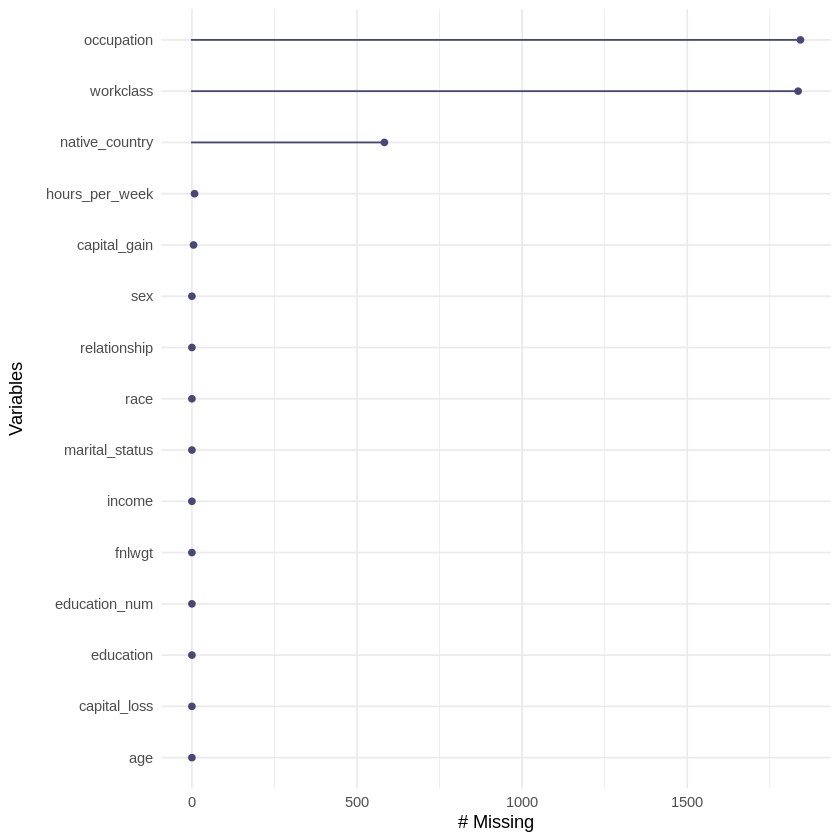

In [10]:
gg_miss_var(adult_dirty)


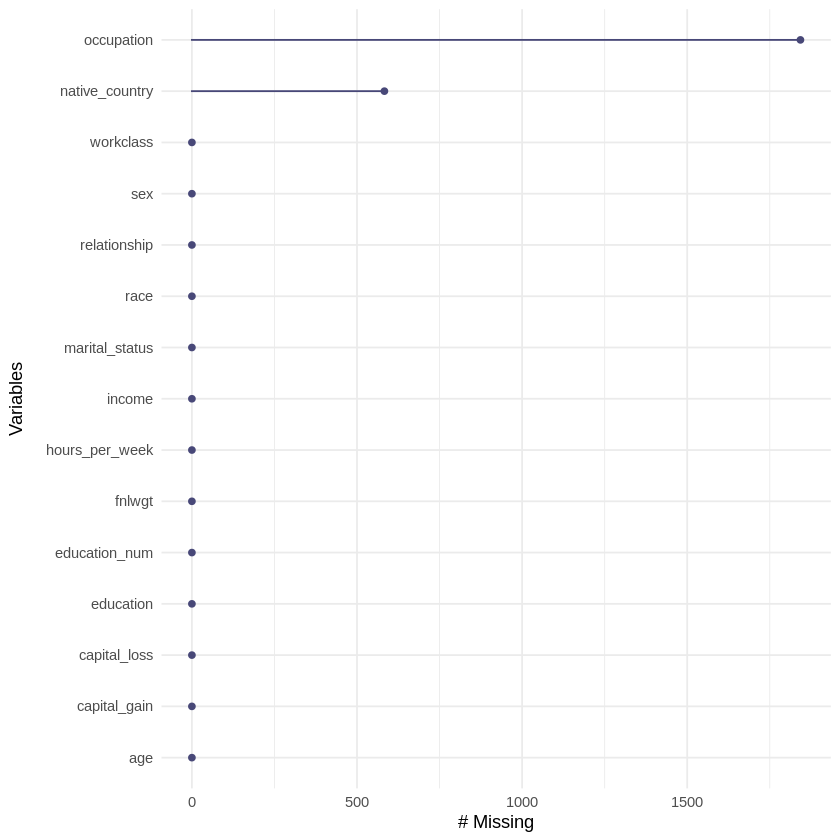

In [11]:
gg_miss_var(adult_clean)


## 6. Task 5 - Validate the cleaned dataset

In [12]:
skim(adult_clean)


,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,workclass,0,1.0000000,7,16,0,9,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,education,0,1.0000000,3,12,0,16,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,marital_status,0,1.0000000,7,21,0,7,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,occupation,1843,0.9433899,5,17,0,14,0,NA,NA,NA,NA,NA,NA,NA,NA
5,character,relationship,0,1.0000000,4,14,0,6,0,NA,NA,NA,NA,NA,NA,NA,NA
6,character,race,0,1.0000000,5,18,0,5,0,NA,NA,NA,NA,NA,NA,NA,NA
7,character,sex,0,1.0000000,4,6,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA
8,character,native_country,583,0.9820924,4,26,0,41,0,NA,NA,NA,NA,NA,NA,NA,NA
9,character,income,0,1.0000000,4,5,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA


In [13]:
cat("Any age == 999 remaining?  ", any(adult_clean$age == 999, na.rm = TRUE), "\n")

cat("NAs remaining in age:            ", sum(is.na(adult_clean$age)), "\n")
cat("NAs remaining in hours_per_week: ", sum(is.na(adult_clean$hours_per_week)), "\n")

cat("Blank strings remaining in workclass:", sum(adult_clean$workclass == "", na.rm = TRUE), "\n")
cat("Genuine NA remaining in workclass:    ", sum(is.na(adult_clean$workclass)), "\n")
cat("Rows now labelled 'Unknown' in workclass:", sum(adult_clean$workclass == "Unknown", na.rm = TRUE), "\n")

stopifnot(
  !any(adult_clean$age == 999, na.rm = TRUE),
  sum(is.na(adult_clean$age)) == 0,
  sum(is.na(adult_clean$hours_per_week)) == 0,
  sum(adult_clean$workclass == "", na.rm = TRUE) == 0,
  sum(is.na(adult_clean$workclass)) == 0
)
cat("\nValidation PASSED.\n")


Any age == 999 remaining?   FALSE 
NAs remaining in age:             0 
NAs remaining in hours_per_week:  0 
Blank strings remaining in workclass: 0 
Genuine NA remaining in workclass:     0 
Rows now labelled 'Unknown' in workclass: 1844 

Validation PASSED.


## 7. Save the cleaned dataset

In [14]:
write.csv(adult_clean, "cleaned_adult_data.csv", row.names = FALSE)
cat("Saved cleaned_adult_data.csv with", nrow(adult_clean), "rows and", ncol(adult_clean), "columns.\n")


Saved cleaned_adult_data.csv with 32556 rows and 15 columns.


## 8. Interpretation / Conclusion

- **`NA`** marks a missing value inside a vector/column and is the correct tool for missing cells in a data frame.
- **`NaN`** ("Not a Number") is a special numeric value that results from undefined arithmetic (e.g. `0/0`); it is a *subtype* of `NA` (`is.na(NaN)` is `TRUE`), but `is.nan()` lets us isolate it specifically.
- **`NULL`** represents the *absence of an R object entirely* (e.g. a list element or function return value that doesn't exist) - it is fundamentally different from a missing value stored *inside* an existing vector, and R does not allow a data-frame cell to literally contain `NULL`.
- **Blank strings `""`** are a distinct data-quality issue from any of the above - they are valid-looking character values that are semantically missing, and must be checked for explicitly with `== ""`.
- After treatment, impossible values were converted to `NA` and then median-imputed, blank categorical entries were relabeled as `"Unknown"` rather than dropped (preserving sample size), and rows with unrecoverable `NaN` were removed since no sensible numeric substitute existed.
- The missingness percentage dropped from a nonzero value before cleaning to effectively 0% for the treated variables after cleaning, and `skimr::skim()` confirms complete, well-typed columns ready for downstream statistical modeling.
